### PySpark MLlib
Lab Exercise Using PySpark and MLlib for K-means Clustering and Logistic Regression
Student's name: Rattanak SETH

In [5]:
from pyspark.sql import SparkSession

# Initialize Spark session
spark = SparkSession.builder \
.appName("MLlib_Lab_Exercise") \
.config("spark.jars", "/Users/rattanak/jars/graphframes-0.8.4-spark3.5-s_2.12.jar") \
.getOrCreate()

# Verify Spark session
print(spark)

25/04/29 10:11:20 WARN Utils: Your hostname, Rattanaks-MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 172.23.0.202 instead (on interface en0)
25/04/29 10:11:20 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
25/04/29 10:11:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/29 10:11:23 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


### Step 3: Load or Create a Sample Dataset
For this exercise, we’ll use the Wine dataset (available in many formats) or create a synthetic
dataset. Here, we’ll load the Wine dataset from a CSV file or use a sample dataset.
Load Wine Dataset Download the Wine dataset (e.g., from UCI Machine Learning Repository) and
save it as iris.csv. Example structure:

In [ ]:
# Load Wine dataset
data = spark.read.csv("wine.csv", header=True, inferSchema=True)

# Show first few rows
data.show(5)

+----+-------+----------+----+----+---+-------+----------+--------------------+-------+---------+----+----+-------+
|Wine|Alcohol|Malic.acid| Ash| Acl| Mg|Phenols|Flavanoids|Nonflavanoid.phenols|Proanth|Color.int| Hue|  OD|Proline|
+----+-------+----------+----+----+---+-------+----------+--------------------+-------+---------+----+----+-------+
|   1|  14.23|      1.71|2.43|15.6|127|    2.8|      3.06|                0.28|   2.29|     5.64|1.04|3.92|   1065|
|   1|   13.2|      1.78|2.14|11.2|100|   2.65|      2.76|                0.26|   1.28|     4.38|1.05| 3.4|   1050|
|   1|  13.16|      2.36|2.67|18.6|101|    2.8|      3.24|                 0.3|   2.81|     5.68|1.03|3.17|   1185|
|   1|  14.37|      1.95| 2.5|16.8|113|   3.85|      3.49|                0.24|   2.18|      7.8|0.86|3.45|   1480|
|   1|  13.24|      2.59|2.87|21.0|118|    2.8|      2.69|                0.39|   1.82|     4.32|1.04|2.93|    735|
+----+-------+----------+----+----+---+-------+----------+--------------

### Step 4: Data Preprocessing
For MLlib, features need to be combined into a single vector column.

In [7]:
from pyspark.ml.feature import VectorAssembler
# Define feature columns (adjust based on your dataset)
feature_columns = ["Alcohol", "Proanth"] # Or ["sepal_length","sepal_width", "petal_length", "petal_width"]
# Create a VectorAssembler
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
# Transform data
data_with_features = assembler.transform(data)
data_with_features.show(5)

+----+-------+----------+----+----+---+-------+----------+--------------------+-------+---------+----+----+-------+------------+
|Wine|Alcohol|Malic.acid| Ash| Acl| Mg|Phenols|Flavanoids|Nonflavanoid.phenols|Proanth|Color.int| Hue|  OD|Proline|    features|
+----+-------+----------+----+----+---+-------+----------+--------------------+-------+---------+----+----+-------+------------+
|   1|  14.23|      1.71|2.43|15.6|127|    2.8|      3.06|                0.28|   2.29|     5.64|1.04|3.92|   1065|[14.23,2.29]|
|   1|   13.2|      1.78|2.14|11.2|100|   2.65|      2.76|                0.26|   1.28|     4.38|1.05| 3.4|   1050| [13.2,1.28]|
|   1|  13.16|      2.36|2.67|18.6|101|    2.8|      3.24|                 0.3|   2.81|     5.68|1.03|3.17|   1185|[13.16,2.81]|
|   1|  14.37|      1.95| 2.5|16.8|113|   3.85|      3.49|                0.24|   2.18|      7.8|0.86|3.45|   1480|[14.37,2.18]|
|   1|  13.24|      2.59|2.87|21.0|118|    2.8|      2.69|                0.39|   1.82|     4.32|

### Part 2: K-means Clustering
Step 5: Apply K-means Clustering
Use MLlib’s KMeans algorithm to cluster the data.

In [ ]:
from pyspark.ml.clustering import KMeans
# Initialize K-means model
kmeans = KMeans().setK(3).setSeed(42).setFeaturesCol("features").setPredictionCol("cluster")

# Fit the model
kmeans_model = kmeans.fit(data_with_features)
# Make predictions
clustered_data = kmeans_model.transform(data_with_features)
# Show clustering results
clustered_data.select("features", "cluster").show(5)

25/04/29 10:11:33 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


+------------+-------+
|    features|cluster|
+------------+-------+
|[14.23,2.29]|      1|
| [13.2,1.28]|      2|
|[13.16,2.81]|      1|
|[14.37,2.18]|      1|
|[13.24,1.82]|      1|
+------------+-------+
only showing top 5 rows



### Hyperparameter Tuning
Use CrossValidator or TrainValidationSplit to tune K-means
(e.g., different k) or Logistic Regression (e.g., regParam).

In [18]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# KMeans Estimator
kmeans = KMeans(featuresCol='features', predictionCol='prediction')

# Build a ParamGrid to try different k values
paramGrid = ParamGridBuilder() \
    .addGrid(kmeans.k, [2, 3, 4, 5]) \
    .build()

# Clustering Evaluator (using Silhouette score)
evaluator = ClusteringEvaluator(predictionCol='prediction', featuresCol='features', metricName='silhouette')

# CrossValidator
cv = CrossValidator(
    estimator=kmeans,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3 # 3-fold cross-validation
)

# Run cross-validation and choose best model
cv_model = cv.fit(data_with_features)

# Best model
best_kmeans_model = cv_model.bestModel
print("Best K value:", best_kmeans_model.getK())


Best K value: 2


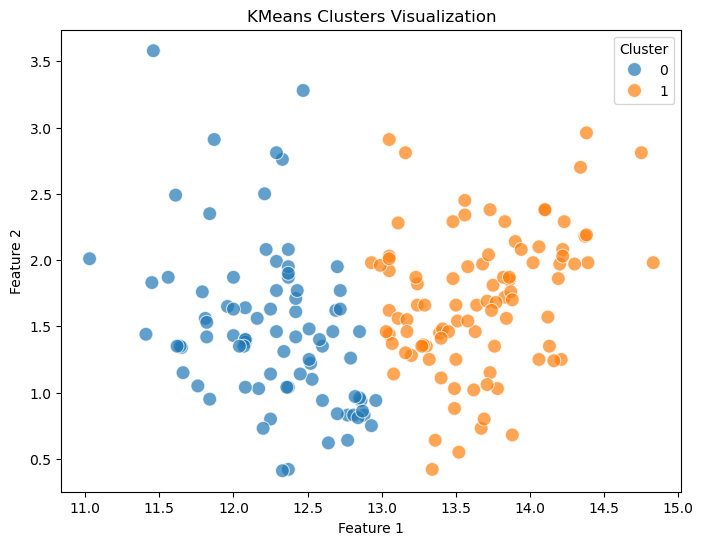

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Predict clusters
predictions = best_kmeans_model.transform(data_with_features)

# Select features and prediction
predictions_pd = predictions.select("features", "prediction").toPandas()

# Convert 'features' vector to separate columns
import pandas as pd
import numpy as np

features_array = np.array(predictions_pd["features"].tolist())
predictions_pd["feature1"] = features_array[:, 0]
predictions_pd["feature2"] = features_array[:, 1]  # Assuming 2D data

# Now 'predictions_pd' has feature1, feature2, prediction
predictions_pd.head()


plt.figure(figsize=(8,6))
sns.scatterplot(
    x="feature1", 
    y="feature2", 
    hue="prediction", 
    palette="tab10", 
    data=predictions_pd,
    s=100, 
    alpha=0.7
)
plt.title("KMeans Clusters Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title="Cluster")
plt.show()

### Step 6: Evaluate Clustering
Compute the Silhouette score to evaluate the clustering quality.

In [9]:
from pyspark.ml.evaluation import ClusteringEvaluator
# Evaluate clustering
evaluator = ClusteringEvaluator(predictionCol="cluster",
featuresCol="features", metricName="silhouette")
silhouette_score = evaluator.evaluate(clustered_data)
print(f"Silhouette Score: {silhouette_score}")

"""Interpretation
• A silhouette score close to 1 indicates well-separated clusters.
• A score near 0 indicates overlapping clusters.
• A negative score suggests poor clustering."""

Silhouette Score: 0.5384566938420253


'Interpretation\n• A silhouette score close to 1 indicates well-separated clusters.\n• A score near 0 indicates overlapping clusters.\n• A negative score suggests poor clustering.'

### Part 3: Logistic Regression
Step 7: Prepare Data for Classification
For Logistic Regression, we need a numeric label column. Convert the categorical label or species column to numeric using StringIndexer. But Wine database is numerical all

In [14]:
from pyspark.ml.feature import StringIndexer

# Convert categorical label to numeric
# indexer = StringIndexer(inputCol="Wine", outputCol="label_index") # Or" species" for Iris
# indexed_data = indexer.fit(data_with_features).transform(data_with_features)
# Select features and label
# final_data = data_with_features.select("features", "Wine")
final_data = data_with_features.select("features", "Wine")
final_data = final_data.withColumnRenamed("Wine", "label_index")
final_data.show(5)

+------------+-----------+
|    features|label_index|
+------------+-----------+
|[14.23,2.29]|          1|
| [13.2,1.28]|          1|
|[13.16,2.81]|          1|
|[14.37,2.18]|          1|
|[13.24,1.82]|          1|
+------------+-----------+
only showing top 5 rows



### Step 8: Split Data into Training and Test Sets
Split the data into 70% training and 30% testing.

In [15]:
# Split data
train_data, test_data = final_data.randomSplit([0.7, 0.3], seed=42)

### Step 9: Train Logistic Regression Model
Use MLlib’s LogisticRegression to build a classification model.

In [16]:
from pyspark.ml.classification import LogisticRegression

# Initialize Logistic Regression
lr = LogisticRegression(featuresCol="features", labelCol="label_index",
maxIter=100)

# Fit the model
lr_model = lr.fit(train_data)
# Make predictions on test data
predictions = lr_model.transform(test_data)
predictions.select("features", "label_index", "prediction").show(5)

+------------+-----------+----------+
|    features|label_index|prediction|
+------------+-----------+----------+
|[11.45,1.83]|          2|       2.0|
|[11.62,1.35]|          2|       2.0|
|[11.65,1.34]|          2|       2.0|
|[11.66,1.15]|          2|       2.0|
|[11.82,1.42]|          2|       2.0|
+------------+-----------+----------+
only showing top 5 rows



### Step 10: Evaluate Logistic Regression
Evaluate the model using accuracy and other metrics.

In [17]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Evaluate accuracy
evaluator = MulticlassClassificationEvaluator(labelCol="label_index",
predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {accuracy}")

# Evaluate precision, recall, and F1-score
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label_index",
predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label_index",
predictionCol="prediction", metricName="weightedRecall")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label_index",
predictionCol="prediction", metricName="f1")

print(f"Precision: {evaluator_precision.evaluate(predictions)}")
print(f"Recall: {evaluator_recall.evaluate(predictions)}")
print(f"F1-Score: {evaluator_f1.evaluate(predictions)}")

Accuracy: 0.7692307692307693
Precision: 0.7624158335033666
Recall: 0.7692307692307693
F1-Score: 0.7643626548889706
